<a href="https://colab.research.google.com/github/rodrigorissettoterra/SENAI_Concepcao_e_Design_de_ML/blob/main/Sistema_de_reconhecimento.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Reconhecimento facial com Yale Face Dataset

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import kagglehub

from PIL import Image
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder

1. Download do dataset via kagglehub

In [2]:
path = kagglehub.dataset_download("olgabelitskaya/yale-face-database")
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'yale-face-database' dataset.
Path to dataset files: /kaggle/input/yale-face-database


2. Função para carregar as imagens

In [3]:
def carregar_imagens(pasta, tamanho=(100, 100)):
    X = []
    y = []

    for root, dirs, files in os.walk(pasta):
        for arquivo in files:
            caminho = os.path.join(root, arquivo)

            # ignora arquivos ocultos e textos auxiliares
            if arquivo.startswith("."):
                continue
            if arquivo.lower().endswith((".txt", ".csv", ".json")):
                continue

            try:
                # abre a imagem mesmo sem extensão convencional
                img = Image.open(caminho).convert("L")
                img = img.resize(tamanho)

                img_array = np.array(img, dtype=np.float32) / 255.0
                img_vector = img_array.flatten()

                # rótulo = subjectXX
                label = arquivo.split(".")[0]

                X.append(img_vector)
                y.append(label)

            except Exception as e:
                print(f"Arquivo ignorado: {arquivo} | Motivo: {e}")

    X = np.array(X, dtype=np.float32)
    y = np.array(y)

    return X, y

3. Carregamento da base

In [4]:
X, y = carregar_imagens(path, tamanho=(100, 100))

print("\nFormato da matriz original:", X.shape)
print("Quantidade de classes:", len(np.unique(y)))
print("Classes encontradas:", np.unique(y))

if X.size == 0:
    raise ValueError(
        "Nenhuma imagem foi carregada. Verifique o conteúdo do dataset."
    )


Formato da matriz original: (330, 10000)
Quantidade de classes: 15
Classes encontradas: ['subject01' 'subject02' 'subject03' 'subject04' 'subject05' 'subject06'
 'subject07' 'subject08' 'subject09' 'subject10' 'subject11' 'subject12'
 'subject13' 'subject14' 'subject15']


4. Codificação dos rótulos

In [5]:
encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)

5. Extração de características com PCA

In [6]:
n_componentes = 50  # N do enunciado: matriz final 165 x N

pca = PCA(n_components=n_componentes, whiten=True, random_state=42)
X_pca = pca.fit_transform(X)

print("\nFormato após PCA:", X_pca.shape)
print("Variância explicada acumulada:", pca.explained_variance_ratio_.sum())


Formato após PCA: (330, 50)
Variância explicada acumulada: 0.9579505


6. Separação entre treino e teste

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X_pca,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print("\nFormato treino:", X_train.shape)
print("Formato teste:", X_test.shape)


Formato treino: (264, 50)
Formato teste: (66, 50)


7. Treinamento do classificador

In [8]:
modelo = SVC(kernel="rbf", class_weight="balanced", random_state=42)
modelo.fit(X_train, y_train)

SVC(class_weight='balanced', random_state=42)

8. Predição e avaliação

In [9]:
y_pred = modelo.predict(X_test)

print("\nAcurácia:", accuracy_score(y_test, y_pred))
print("\nRelatório de Classificação:\n")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=encoder.classes_,
        zero_division=0
    )
)


Acurácia: 1.0

Relatório de Classificação:

              precision    recall  f1-score   support

   subject01       1.00      1.00      1.00         4
   subject02       1.00      1.00      1.00         4
   subject03       1.00      1.00      1.00         4
   subject04       1.00      1.00      1.00         5
   subject05       1.00      1.00      1.00         5
   subject06       1.00      1.00      1.00         4
   subject07       1.00      1.00      1.00         5
   subject08       1.00      1.00      1.00         5
   subject09       1.00      1.00      1.00         4
   subject10       1.00      1.00      1.00         4
   subject11       1.00      1.00      1.00         5
   subject12       1.00      1.00      1.00         4
   subject13       1.00      1.00      1.00         5
   subject14       1.00      1.00      1.00         4
   subject15       1.00      1.00      1.00         4

    accuracy                           1.00        66
   macro avg       1.00      1.00  

9. Matriz de confusão

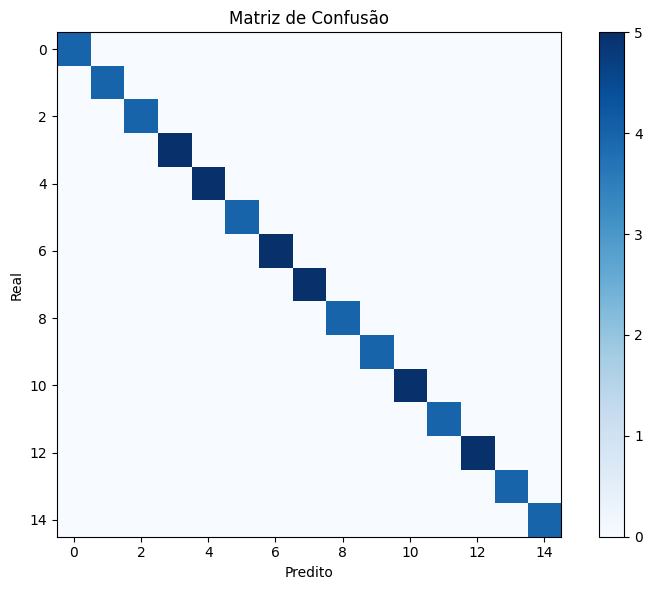

In [10]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
plt.imshow(cm, cmap="Blues")
plt.title("Matriz de Confusão")
plt.colorbar()
plt.xlabel("Predito")
plt.ylabel("Real")
plt.tight_layout()
plt.show()

10. Visualização das eigenfaces

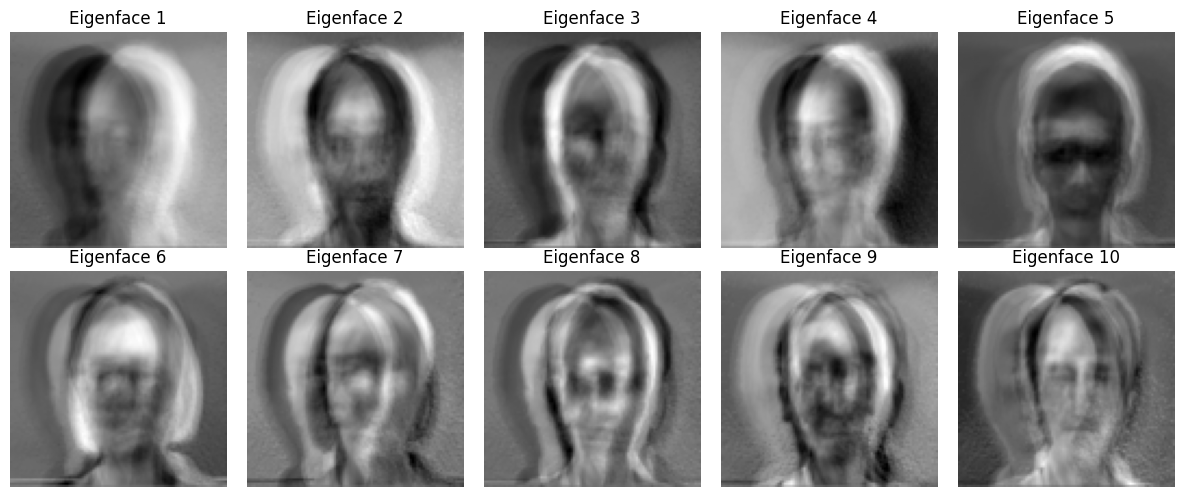

In [11]:
eigenfaces = pca.components_.reshape((n_componentes, 100, 100))

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(eigenfaces[i], cmap="gray")
    ax.set_title(f"Eigenface {i+1}")
    ax.axis("off")
plt.tight_layout()
plt.show()

11. Exemplo de predição

In [12]:
indice = 0
amostra = X_test[indice].reshape(1, -1)
classe_real = encoder.inverse_transform([y_test[indice]])[0]
classe_prevista = encoder.inverse_transform(modelo.predict(amostra))[0]

print("\nExemplo de predição:")
print("Classe real:", classe_real)
print("Classe prevista:", classe_prevista)


Exemplo de predição:
Classe real: subject05
Classe prevista: subject05


12. Matriz final solicitada no exercício

In [13]:
print("\nMatriz final de características (165 x N, ou quantidade equivalente encontrada):")
print(X_pca)
print("\nShape final:", X_pca.shape)


Matriz final de características (165 x N, ou quantidade equivalente encontrada):
[[-6.1617768e-01  2.6091516e-01  1.4900514e+00 ... -4.2517757e-01
   4.2152849e-01  4.7463119e-01]
 [ 5.7192844e-01  1.0252366e+00  4.3751318e-02 ... -1.3380907e-01
   6.6293228e-01 -1.4752984e+00]
 [ 1.1874504e+00 -2.2579982e+00 -1.7462782e+00 ...  1.0664824e+00
   4.1261721e-01  4.0342391e-02]
 ...
 [ 1.6825892e+00 -1.4937155e-01  1.2121110e+00 ...  3.2703939e-01
  -4.2843167e-04 -2.5981766e-01]
 [-1.1851301e+00 -9.7015977e-01  1.2861142e+00 ... -9.0518218e-01
  -6.4567882e-01 -9.2552567e-01]
 [ 3.0288512e-01  1.0134335e+00 -8.5958272e-01 ... -4.4162238e-01
  -4.4334799e-01  2.9057434e+00]]

Shape final: (330, 50)
